<a href="https://colab.research.google.com/github/Lukman289/Pengolahan-Citra-dan-Visi-Komputer/blob/main/Modul_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

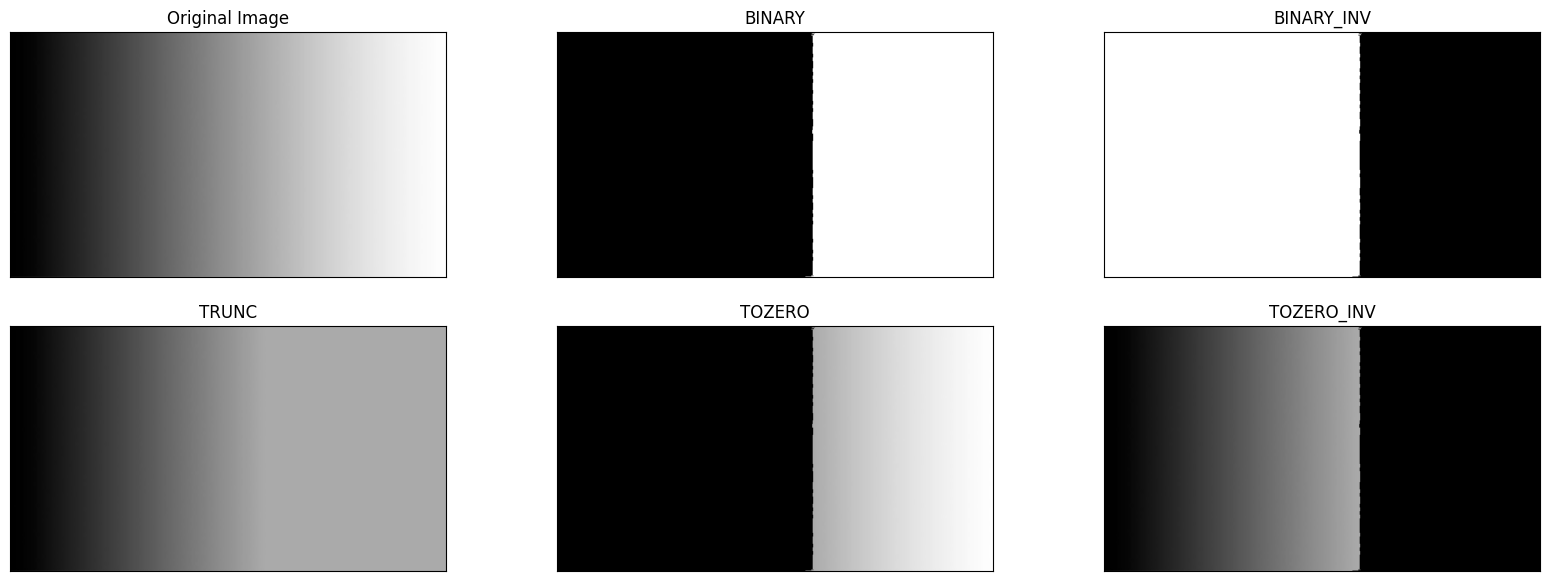

In [3]:
img1 = cv2.imread('/content/drive/MyDrive/Kuliah /Semester 5/Pengolahan Citra dan Visi Komputer/img/gradient.jpg')
threshold_value = 170

ret,thresh1 = cv2.threshold(img1,threshold_value,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img1,threshold_value,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img1,threshold_value,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img1,threshold_value,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img1,threshold_value,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img1, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(20,7))
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])

plt.show()

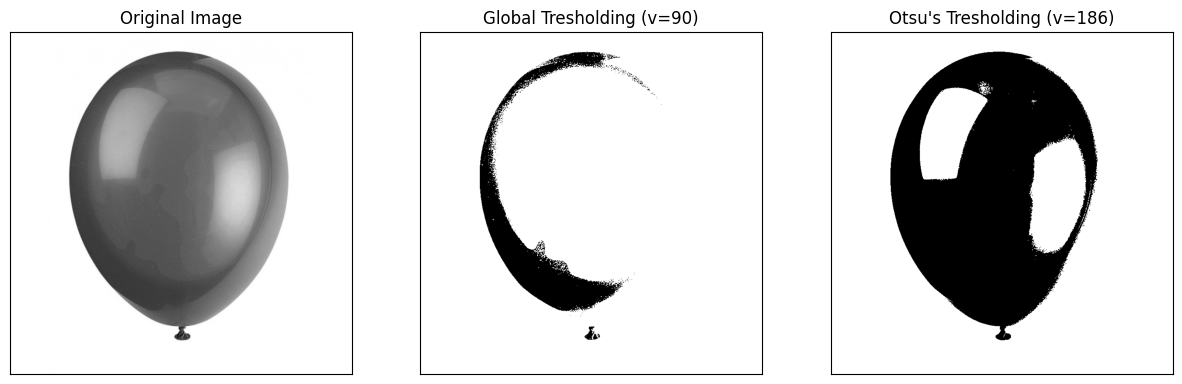

In [4]:
img2 = cv2.imread('/content/drive/MyDrive/Kuliah /Semester 5/Pengolahan Citra dan Visi Komputer/img/balloon.jpg', cv2.IMREAD_GRAYSCALE)

# Calculate histogram
hist = cv2.calcHist([img2],[0],None,[256],[0,256])

# Calculate probabilities and weighted sums
p = hist / np.sum(hist)
weighted_sum = np.arange(256) * p

# Calculate between-class variance
variance = np.zeros(256)
for i in range(256):
  w0 = np.sum(p[:i])
  w1 = np.sum(p[i:])
  if w0 == 0 or w1 == 0:
    continue
  mean0 = np.sum(weighted_sum[:i]) / w0
  mean1 = np.sum(weighted_sum[i:]) / w1
  variance[i] = w0 * w1 * (mean0 - mean1) ** 2

# Find the threshold that maximizes between-class variance
threshold_otsu = np.argmax(variance)

# Apply Otsu's thresholding
ret, thresh_otsu = cv2.threshold(img2, threshold_otsu, 255, cv2.THRESH_BINARY)

# Apply global thresholding (for comparison)
threshold_global = 90
ret, thresh_global = cv2.threshold(img2, threshold_global, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1),plt.imshow(img2,'gray'),plt.title('Original Image'),plt.xticks([]),plt.yticks([])
plt.subplot(1,3,2),plt.imshow(thresh_global,'gray'),plt.title('Global Tresholding (v=90)'),plt.xticks([]),plt.yticks([])
plt.subplot(1,3,3),plt.imshow(thresh_otsu,'gray'),plt.title('Otsu\'s Tresholding (v=186)'),plt.xticks([]),plt.yticks([])

plt.show()

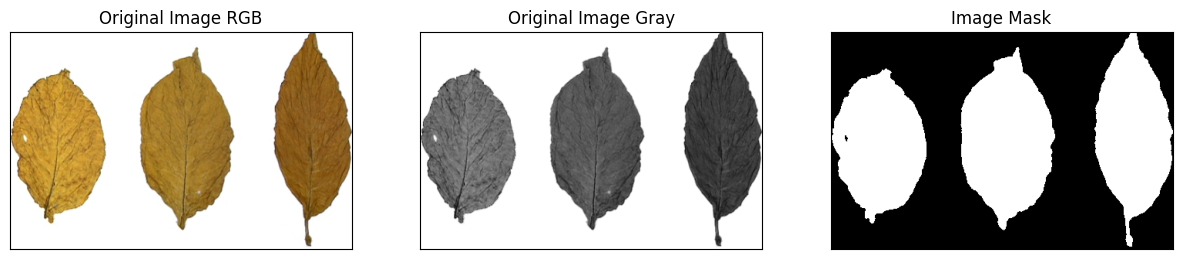

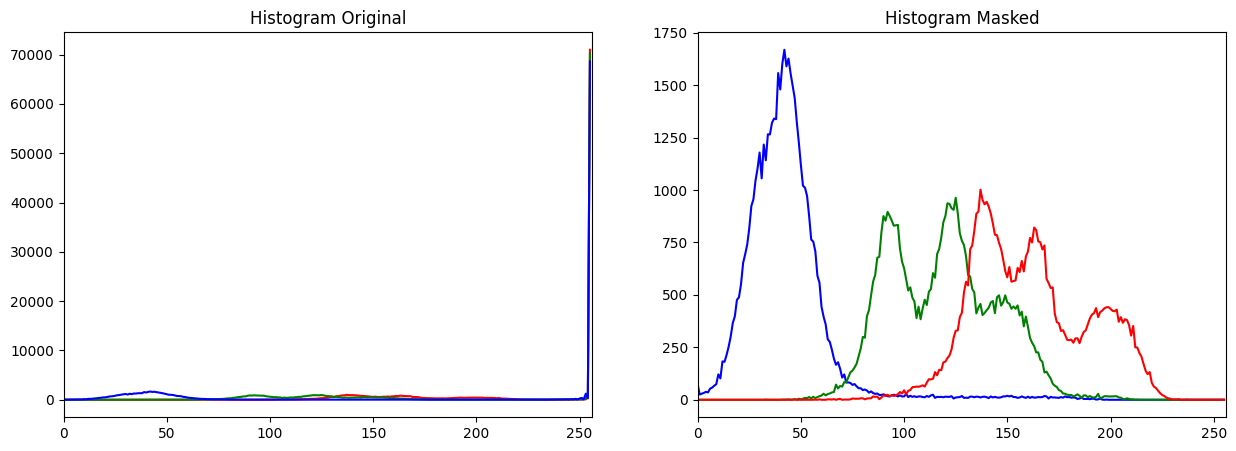

In [35]:
img3 = cv2.imread('/content/drive/MyDrive/Kuliah /Semester 5/Pengolahan Citra dan Visi Komputer/img/tobacco.jpg', 1)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

# Convert to grayscale
img3_gray = cv2.cvtColor(img3_rgb, cv2.COLOR_BGR2GRAY)

# Apply Otsu's thresholding
_, img3_mask = cv2.threshold(img3_gray,200,255,cv2.THRESH_BINARY_INV)

# Display original image, grayscale image, image mask
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(img3_rgb, 'gray'), plt.title('Original Image RGB'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 2), plt.imshow(img3_gray, 'gray'), plt.title('Original Image Gray'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 3, 3), plt.imshow(img3_mask, 'gray'), plt.title('Image Mask'), plt.xticks([]), plt.yticks([])
plt.show()

# Separating color layers of original images
hist1_red = cv2.calcHist(
            images = [img3_rgb],
            channels = [0],
            mask = None,
            histSize = [256],
            ranges = [0,256]
        )
hist1_green = cv2.calcHist(
            images = [img3_rgb],
            channels = [1],
            mask = None,
            histSize = [256],
            ranges = [0,256]
        )
hist1_blue = cv2.calcHist(
            images = [img3_rgb],
            channels = [2],
            mask = None,
            histSize = [256],
            ranges = [0,256]
        )

hist2_blue = cv2.calcHist(
            images = [img3],
            channels = [0],
            mask = img3_mask,
            histSize = [256],
            ranges = [0,256]
        )
hist2_green = cv2.calcHist(
            images = [img3],
            channels = [1],
            mask = img3_mask,
            histSize = [256],
            ranges = [0,256]
        )
hist2_red = cv2.calcHist(
            images = [img3],
            channels = [2],
            mask = img3_mask,
            histSize = [256],
            ranges = [0,256]
        )

# Display histogram original image
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title('Histogram Original')
plt.plot(hist1_red, color='r')
plt.plot(hist1_green, color='g')
plt.plot(hist1_blue, color='b')
plt.xlim([0, 256])

# Display histogram image mask
plt.subplot(1, 2, 2)
plt.title('Histogram Masked')
plt.plot(hist2_blue, color='b')
plt.plot(hist2_green, color='g')
plt.plot(hist2_red, color='r')
plt.xlim([0, 256])
plt.show()

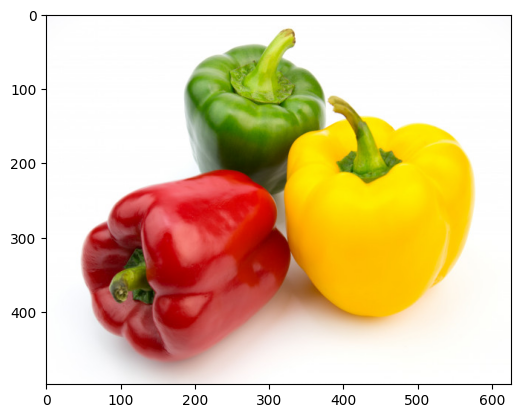

In [40]:
img4 = cv2.imread('/content/drive/MyDrive/Kuliah /Semester 5/Pengolahan Citra dan Visi Komputer/img/peppers.jpg')
img4_rgb = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

plt.imshow(img4_rgb)

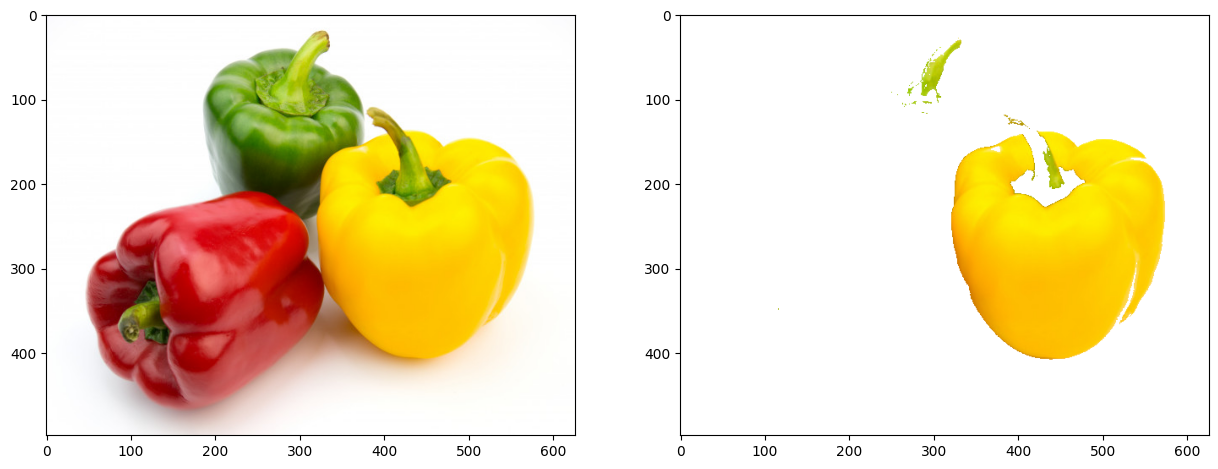

In [57]:
from sklearn.cluster import KMeans
#reshape array ke bentuk 2D
pixel_values = img4_rgb.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 5
_, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]
# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img4_rgb.shape)

masked_img4 = np.copy(img4_rgb)
# konvert ke bentuk vektor
masked_img4 = masked_img4.reshape((-1, 3))
# cluster yang diubah
masked_img4[labels == 4] = [255,255,255]
masked_img4[labels == 2] = [255,255,255]
masked_img4[labels == 3] = [255,255,255]
masked_img4[labels == 1] = [255,255,255]

# konvert ke bentuk asli
masked_img4 = masked_img4.reshape(img4_rgb.shape)
plt.figure(figsize = (15,10))
plt.subplot(1,2,1),plt.imshow(img4_rgb)
plt.subplot(1,2,2),plt.imshow(masked_img4)
plt.show()

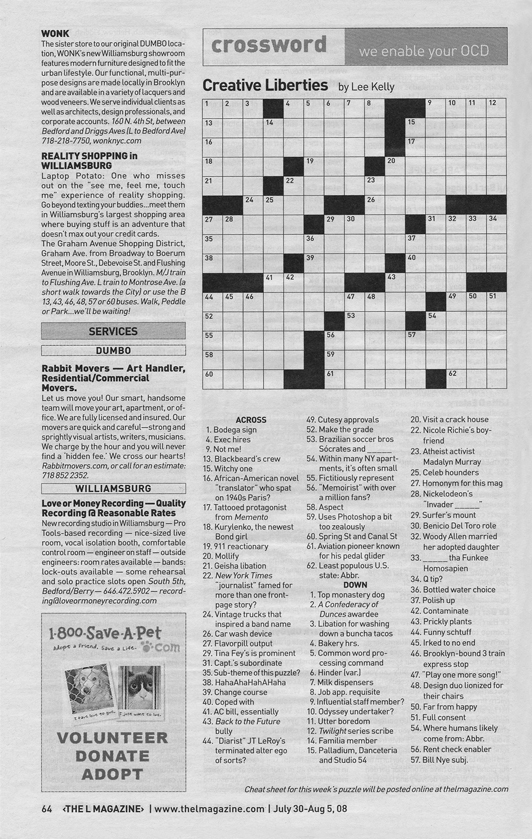

In [75]:
from google.colab.patches import cv2_imshow
img5 = cv2.imread('/content/drive/MyDrive/Kuliah /Semester 5/Pengolahan Citra dan Visi Komputer/img/crossword.jpg', 0)
cv2_imshow(img5)

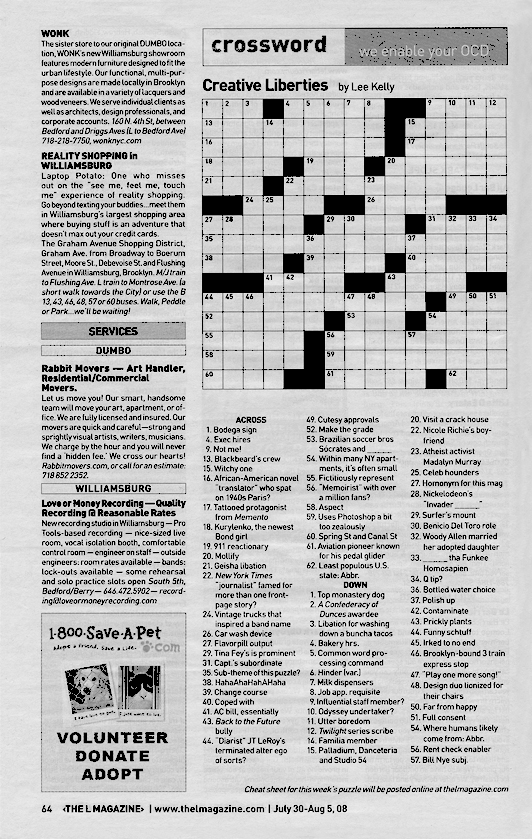

In [86]:
# _, img5_TZ = cv2.threshold(img5, 127, 255, cv2.THRESH_TOZERO)
# cv2_imshow(img5_TZ)
_, img5_binary = cv2.threshold(img5, 127, 255, cv2.THRESH_BINARY+cv2.THRESH_TOZERO)
cv2_imshow(img5_binary)